# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [46]:




# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




In [2]:


# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage =pd.read_csv('/datasets/usage.csv')



In [3]:



# mostrar las primeras 5 filas de plans

plans.head(5)





,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:


# mostrar las primeras 5 filas de users
users.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:

# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:

# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:


# inspección de users con .info()
users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:


# inspección de usage con .info()
usage.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:





# cantidad de nulos para users
users_nulos= users.isna().sum()

print("Cantidad de nulos users" ,users_nulos)

# proporcion de valores nulos

proporcion_valores_nulos_users= users.isna().mean().sort_values(ascending=False)

print ("Proporcion de valores users", proporcion_valores_nulos_users)






Cantidad de nulos users user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporcion de valores users churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [11]:


# cantidad de nulos para usage

usage_nulos= usage.isna().sum()

print("Cantidad de nulos usage " ,usage_nulos)

# proporcion de valores nulos

proporcion_valores_nulos_usage= usage.isna().mean().sort_values(ascending=False)

print ("Proporcion de valores nulos usage", proporcion_valores_nulos_usage)



Cantidad de nulos usage  id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporcion de valores nulos usage duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
SE PUEDE DETERMINAR QUE LOS VALORES AUSENTES DE LA COLUMNA CHURN, SE DEBEN A USUARIOS QUE AUN ESTAN ACTIVOS EN CONECTA TEL.
EN CUANTO A LAS COLUMNAS DURATION Y LENGHT, LOS NULOS SE DEBEN A QUE EN LAS LLAMADAS NO HAY TEXTOS , Y VICECERSA.SE IMMPUTAN COMO VALORES NULOS POR ESA RAZON. NAN
EN CUANTO A CITY , OPTARIA POR AGRUPAR LOS DATOS NULOS EN UNA CATEGORIA UNKONOWUN  PARA NO PERDER ESE 11 PORCIENTO DE DATOS EN OTROS ANALISIS. 
💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  EN USERS, LAS COLUMNAS CITY(469 , 11.7) Y CHURN DATE (3534,88.3%)
  EN USAGE duration (22076,55%), length (17896,44.7%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
.churn_date → Eliminar (porque los NaN son válidos: usuario activo)
.duration y length → Dejar NaN (son estructuralmente correctos)
.city → Imputar con "Unknown" (para no perder usuarios ni inventar datos)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:




# explorar columnas numéricas de users
columnas_numericas_users= ["user_id","age"]
users[columnas_numericas_users].describe()





,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` -  Es solo un identificador, las estadísticas no tienen significado real.
- La columna `age` - El .describe() es útil para detectar valores imposibles como -999. Es un valor sentinel

In [13]:






# explorar columnas numéricas de usage
columnas_numericas_usage= ["id","user_id"]
usage[columnas_numericas_usage].describe()








,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- La columna user_id coincide en rango con la de la columna users. En cuanto a id, tiene un maximo de 40.000 y un minimo de 1 lo cual es exactamente el numero de registros. 

In [14]:




# explorar columnas categóricas de users
columnas_categoricas_user = ['city', 'plan']
users[columnas_categoricas_user].describe()
users[columnas_categoricas_user].value_counts()





city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` ...tiene un valor sentinel: el signo de interrogación "?".
un sentinel es un valor que se usa para indicar "dato desconocido", pero que no es un nulo real.
l siguiente paso está en reemplazar ese "?" por un valor nulo real (pd.NA).
- La columna `plan` ...se ve bien, solo tiene los valores esperados: "Basico" y "Premium".

In [75]:






# explorar columna categórica de usage
usage['type'].value_counts()





0

- La columna `type` ...solo tiene "text" y "call", que son exactamente los valores esperados


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En la columna age, el valor sentinel -999 , y en la columna city otro, el valor ? .
- ¿Qué acción tomarías?  hay que imputarlos, la edad por la media o la mediana y en la ciudad por un valor unknown

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:






# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'].str[:26], errors='coerce')


print(users['reg_date'])







0      2022-01-01 00:00:00.000000
1      2022-01-01 06:34:17.914478
2      2022-01-01 13:08:35.828957
3      2022-01-01 19:42:53.743435
4      2022-01-02 02:17:11.657914
                  ...            
3995   2024-12-29 21:42:48.342085
3996   2024-12-30 04:17:06.256564
3997   2024-12-30 10:51:24.171042
3998   2024-12-30 17:25:42.085521
3999   2024-12-31 00:00:00.000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]


In [17]:






# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'].str[:26],errors="coerce")


print(usage['date'])






0       2024-01-01 00:00:00.000000
1       2024-01-01 00:06:30.969774
2       2024-01-01 00:13:01.939548
3       2024-01-01 00:19:32.909322
4       2024-01-01 00:26:03.879096
                   ...            
39995   2024-06-29 23:33:56.120903
39996   2024-06-29 23:40:27.090677
39997   2024-06-29 23:46:58.060451
39998   2024-06-29 23:53:29.030225
39999   2024-06-30 00:00:00.000000
Name: date, Length: 40000, dtype: datetime64[ns]


In [18]:


# Revisar los años presentes en `reg_date` de users
años_presentes = users['reg_date'].dt.year.unique()
print(años_presentes)



[2022 2026 2023 2024]



En `reg_date`, ... haz doble clic en este bloque y escribe qué ves. 
Figuran registros del 2026, lo cual es imposible , demostrando que tenemos un sentinel 


In [19]:



# Revisar los años presentes en `date` de usage
años_presentes = usage['date'].dt.year.unique()
print(años_presentes)






[2024.   nan]


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas. 
El resultado [2024.   nan] nos dice dos cosas:

2024 → todos los registros de usage['date'] son del año 2024 ✅ (sin fechas imposibles)
nan → hay algunos valores nulos (los 50 que ya detectamos en el paso 2.1)
Entonces, a diferencia de reg_date que tenía el año 2026 (imposible), la columna date de usage no tiene fechas fuera de rango, solo algunos nulos

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) 
- ¿Qué harías con ellas?
  En reg_date → marcar como nulas las fechas fuera de rango.Entonces la acción correcta es convertir esas fechas del 2026 en nulos (NaT), no en "unknown".

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:


# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:

# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()



count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:



# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].describe()




count                           3960
unique                          3960
top       2023-07-15 05:34:53.023255
freq                               1
first            2022-01-01 00:00:00
last             2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:



# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)





type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:




# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)





type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
. call → 0.999: casi el 100% de los nulos en length ocurren en llamadas ✅
text → 0.000: ningún mensaje de texto tiene nulo en length ✅
Esto confirma que tanto duration como length son MAR — los nulos no son errores, sino que dependen estructuralmente del tipo de registro.

Como los nulos en duration y length dependen estructuralmente del tipo de registro (call o text), no son errores — son datos válidos que simplemente no aplican. Dejarlos como NaN es la decisión correcta.


## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=("is_text",'sum'),
    cant_llamadas=("is_call",'sum'),
    cant_minutos_llamada=('length','sum')
).reset_index()

# observar resultado

usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [26]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [27]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg,on='user_id',how='left')
user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000,Basico,NaN,7.0,3.0,258.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478,Basico,NaN,5.0,10.0,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957,Basico,NaN,5.0,2.0,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435,Premium,NaN,11.0,3.0,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914,Basico,NaN,4.0,3.0,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:


user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada']]=user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada']].fillna(0)


# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()








,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.122250,5.523000,4.477000,288.056000
std,17.690408,2.359738,2.145139,180.941581
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,183.750000
50%,47.000000,5.000000,4.000000,268.000000
75%,63.000000,7.000000,6.000000,361.000000
max,79.000000,17.000000,15.000000,2028.000000


In [29]:



# Distribución porcentual del tipo de plan


user_profile['plan'].value_counts(normalize=True)*100





Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

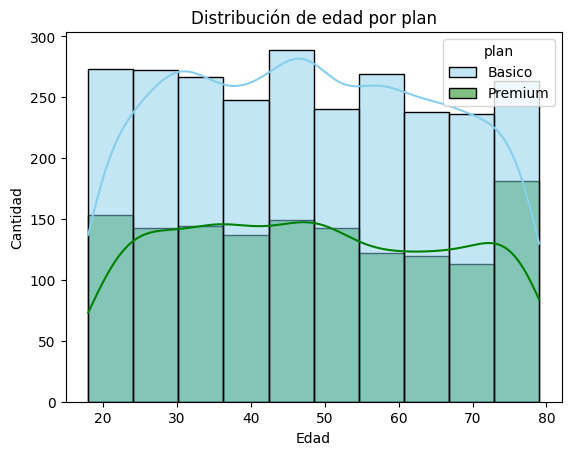

In [30]:


# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()
plt.show()




💡Insights: 
- Distribución ...
"La distribución de edad es simétrica, con mayor concentración entre los 40 y 50 años. No se observan diferencias significativas entre usuarios Básico y Premium, lo que sugiere que la edad no es un factor diferenciador en la elección del plan."

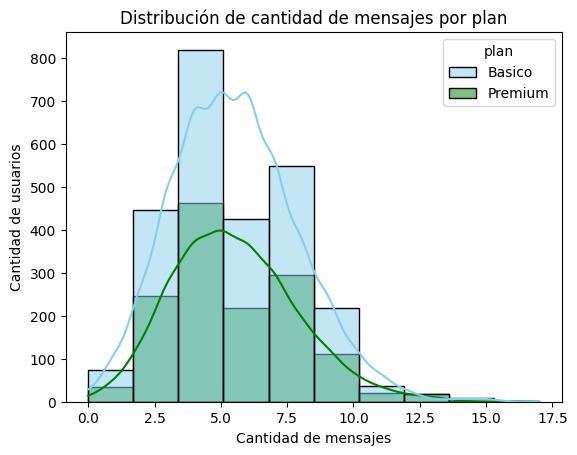

In [31]:


# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()
plt.show()




💡Insights: 
- La columna cantidad de mensajes tiene una distribucion con sesgo hacia la derecha , tanto para planes basicos como premium. La mayoria de los usuarios se concentran entre 2.5 y 5 mensajes , con algun casi aislado que puede alcanzar los 20 msj, para ambos planes,esto sugiere que la mayoría de usuarios no hace un uso intensivo de mensajes.

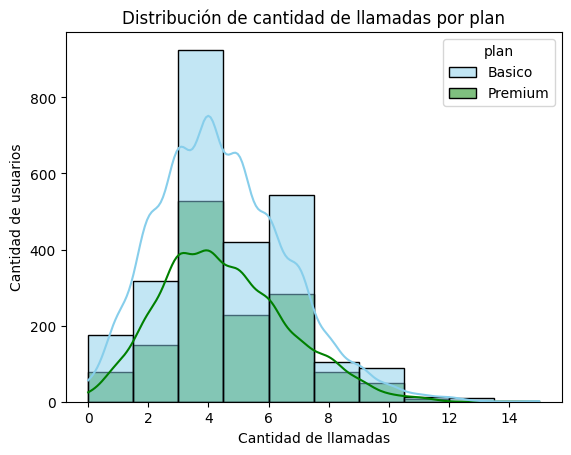

In [32]:


# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()




💡Insights: 
- - La columna cantidad de llamadas tiene una distribucion con sesgo hacia la derecha , tanto para planes basicos como premium. La mayoria de los usuarios se concentran entre 3 y 6 llamadas , con algun casi aislado que puede alcanzar las 15 , para ambos planes,esto sugiere que la mayoría de usuarios no hace un uso intensivo de llamadas.

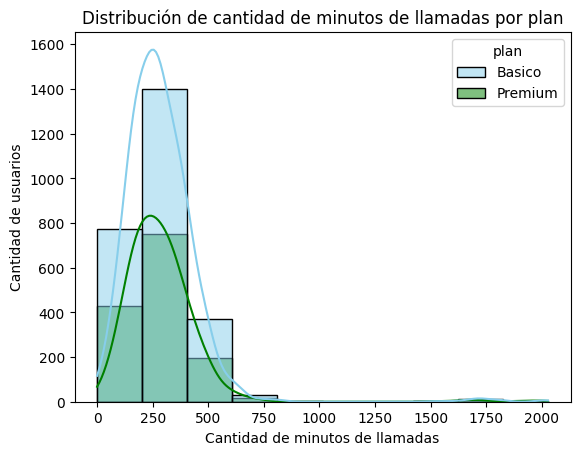

In [33]:

# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de minutos de llamadas por plan')
plt.xlabel('Cantidad de minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- La columna cantidad de minutos de llamadas tiene una distribucion con sesgo hacia la derecha , tanto para planes basicos como premium. La mayoria de los usuarios se concentran entre 180 y 360 minutos , y se observa un outlier que amplia el sesgo con un valor de 2028 minutos. Los usuarios de ambos planes hacen un uso moderado del servicio, sin muchas diferencias.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

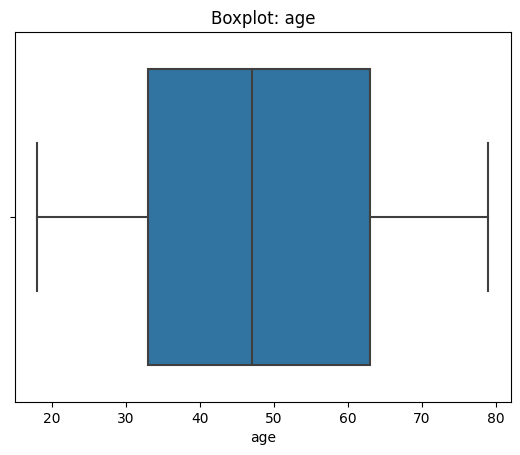

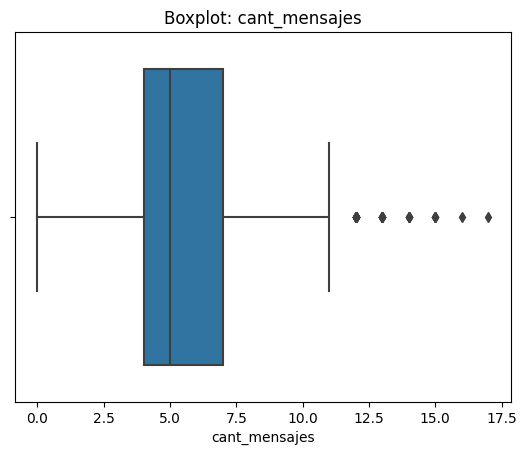

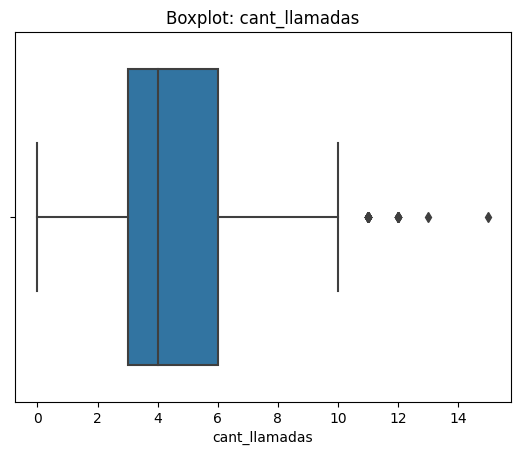

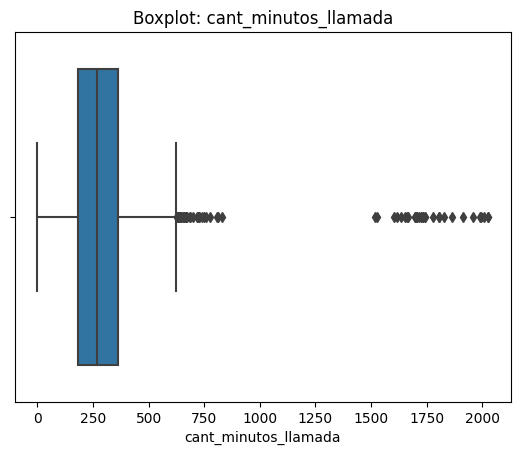

In [34]:


# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas :
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()



💡Insights: 
- Age: sin outliers
- cant_mensajes: tiene pocos outliers,que no generan mucho ruido
- cant_llamadas: tiene pocos outliers,que no generan mucho ruido
- cant_minutos_llamada: es el grafico mas afectado por la presencia de outliers hacia la derecha

In [35]:


# Calcular límites con el método IQR
# Dado que todos los outliers están solo del lado derecho (superior), solo necesitas calcular el límite superior.
# limite_superior = Q3 + 1.5* IQR
#cant_minutos_llamadas

Q1_minutos_llamadas=user_profile['cant_minutos_llamada'].quantile(0.25)
Q3_minutos_llamadas=user_profile['cant_minutos_llamada'].quantile(0.75)
IQR_minutos_llamadas= Q3_minutos_llamadas-Q1_minutos_llamadas
limite_superior_minutos_llamadas = Q3_minutos_llamadas + 1.5*IQR_minutos_llamadas

print('lim_sup_min_llam',limite_superior_minutos_llamadas)

#cant_mensajes

Q1_mensajes=user_profile['cant_mensajes'].quantile(0.25)
Q3_mensajes=user_profile['cant_mensajes'].quantile(0.75)
IQR_mensajes=Q3_mensajes-Q1_mensajes
limite_superior_mensajes =Q3_mensajes + 1.5*IQR_mensajes

print('lim_sup_mensajes',limite_superior_mensajes)

#cant_llamadas

Q1_llamadas=user_profile['cant_llamadas'].quantile(0.25)
Q3_llamadas=user_profile['cant_llamadas'].quantile(0.75)
IQR_llamadas=Q3_llamadas-Q1_llamadas
limite_superior_llamadas=Q3_llamadas + 1.5*IQR_llamadas

print('lim_sup_llamadas',limite_superior_llamadas)




lim_sup_min_llam 626.875
lim_sup_mensajes 11.5
lim_sup_llamadas 10.5


In [36]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print(user_profile['cant_minutos_llamada'].describe())
print(user_profile['cant_mensajes'].describe())
print(user_profile['cant_llamadas'].describe())



count    4000.000000
mean      288.056000
std       180.941581
min         0.000000
25%       183.750000
50%       268.000000
75%       361.000000
max      2028.000000
Name: cant_minutos_llamada, dtype: float64
count    4000.000000
mean        5.523000
std         2.359738
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64
count    4000.000000
mean        4.477000
std         2.145139
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? se pueden mantener, no difieren mucho el maximo del limite superior
- cant_llamadas: mantener o no outliers, porqué? se pueden mantener, no difieren mucho el maximo del limite superior
- cant_minutos_llamada: mantener o no outliers, porqué? aqui hay una notable diferencia, lo que nos obliga a reemplazar el outlier por el valor del limite superior

In [37]:


# REEMPLAZO DE OUTLIERS EN COLUMNA : cant_minutos_llamada
user_profile.loc[user_profile['cant_minutos_llamada'] > limite_superior_minutos_llamadas,'cant_minutos_llamada'] = limite_superior_minutos_llamadas


print(user_profile['cant_minutos_llamada'].describe())




count    4000.000000
mean      278.942125
std       128.327172
min         0.000000
25%       183.750000
50%       268.000000
75%       361.000000
max       626.875000
Name: cant_minutos_llamada, dtype: float64


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [55]:



# Crear columna grupo_uso
#sin funcion np.where 
user_profile['grupo_uso']=np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes']<5), 'Bajo uso',
    np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes']<10), 'Uso Medio',
     'Alto uso',
            )
)
 




In [59]:


# verificar cambios
user_profile.head()







,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000,Basico,NaN,7.0,3.0,258.0,Uso Medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478,Basico,NaN,5.0,10.0,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957,Basico,NaN,5.0,2.0,225.0,Uso Medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435,Premium,NaN,11.0,3.0,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914,Basico,NaN,4.0,3.0,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [61]:



# Crear columna grupo_edad
#sin funcion np.where 
user_profile['grupo_edad']=np.where(
    (user_profile['age'] < 30),'Joven',
    np.where((user_profile['age'] < 60),'Adulto', 'Adulto Mayor',
            )
)




In [62]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000,Basico,NaN,7.0,3.0,258.0,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478,Basico,NaN,5.0,10.0,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957,Basico,NaN,5.0,2.0,225.0,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435,Premium,NaN,11.0,3.0,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914,Basico,NaN,4.0,3.0,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

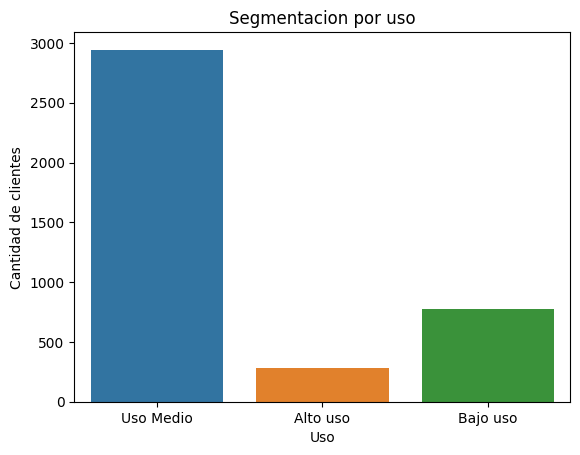

In [72]:







# Visualización de los segmentos por uso


sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Segmentacion por uso')
plt.xlabel('Uso')
plt.ylabel('Cantidad de clientes')
plt.show()










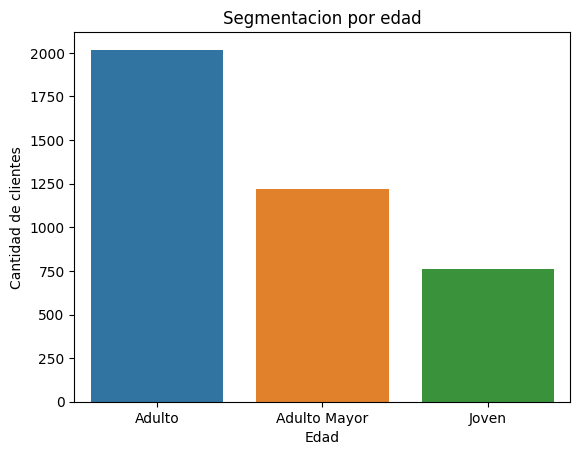

In [73]:


# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Segmentacion por edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.show()






In [78]:
user_profile['grupo_edad'].value_counts()/4000*100

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64

In [79]:
user_profile['grupo_uso'].value_counts()/4000*100

Uso Medio    73.575
Bajo uso     19.475
Alto uso      6.950
Name: grupo_uso, dtype: float64


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
1. Valores nulos (NaN)

.city en users: 469 filas nulas → 11.7%
.churn_date en users: 3,534 filas nulas → 88.3% (aunque estos son válidos: usuarios activos)
.duration en usage: 22,076 filas nulas → 55.2% (válidos: son textos, no llamadas)
.length en usage: 17,896 filas nulas → 44.7% (válidos: son llamadas, no textos)
.date en usage: 50 filas nulas → 0.1%
2. Valores sentinel

age en users: valor -999. Se detectaron valores sentinel (-999) en la columna age, evidenciados por el mínimo de -999 y la desviación estándar anormalmente alta (123.23) en el resumen estadístico previo a la limpieza. Fueron reemplazados por la mediana.
city en users: valor "?" → 96 filas (65 Básico + 31 Premium).
3. Fechas fuera de rango

reg_date en users: registros con año 2026 →  40 filas con fechas imposibles.
4. Outliers

cant_minutos_llamada: máximo de 2,028 minutos vs. límite superior IQR de 626.9 minutos.


🔍 **Segmentos por Edad**
Por edad:

Adulto: 50.45%
Adulto Mayor: 30.55%
Joven: 19.00%



📊 **Segmentos por Nivel de Uso**
-Por nivel de uso:

Uso Medio: 73.58%
Bajo uso: 19.48%
Alto uso: 6.95%

➡️ Esto sugiere que ...
La mayoría son Adultos → enfocar campañas hacia ellos
La mayoría tiene Uso Medio → no necesitan planes gigantes
Conclusión → ofrecer planes más accesibles y ajustados al uso real.

Adultos (50.45%) → planes de datos accesibles + campañas de marketing dirigidas
Adultos Mayores (30.55%) → planes con muchas llamadas a bajo costo
Jóvenes (19%) → planes con muchos datos móviles

💡 **Recomendaciones**
            1.Segmento Adultos Mayores (30.55% de la base): Lanzar el "Plan Conectados Senior" a un precio de $10/mes, que incluya 500 minutos de llamadas nacionales, bloque de números frecuentes gratuitos y una interfaz de soporte simplificada por WhatsApp. El objetivo es asegurar la retención de este tercio de la base mediante un producto de alta percepción de valor y bajo costo operativo.                   2. Estrategia para el Grupo de Alto Uso (6.95%) :Este grupo es pequeño en volumen pero crítico en consumo (y probablemente en riesgo de abandono si se sienten limitados).
Recomendación: Diseñar el plan "Connecta Max Premium" a un precio de $35 a $40/mes, ofreciendo datos y minutos ilimitados, roaming internacional básico incluido y atención al cliente prioritaria (Soporte VIP). La acción clave es enviar una campaña de preventa exclusiva por SMS/Email a este 6.95% ofreciéndoles un "upgrade" directo con el primer mes al 50% de descuento para blindarlos contra la competencia.             3. Estrategia de Migración para el Plan Básico (64.9%) :Tener casi dos tercios de la base estancados en el plan más bajo es un riesgo de ingresos, pero también una mina de oro para el Up-selling (vender un plan superior). Recomendación: Implementar una estrategia de migración escalonada (Upselling) mediante un "Plan Intermedio Puente" a $15/mes (un escalón arriba del básico). Para incentivarlos, se ejecutará una campaña de "Prueba Gratuita": se les otorgarán los beneficios del plan intermedio durante 2 meses sin costo adicional. Al finalizar el periodo, el cliente podrá mantener el plan pagando la nueva tarifa o solicitar manualmente la baja al plan básico.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`